#EDA (EXPLORACION DE DATOS)

In [152]:
#Importacion de librerias

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
url='https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/feature/ds-notebooks-modelos/data/raw/dataset_crudo.csv'
df = pd.read_csv(url)

##Estadística Descriptiva

In [62]:
#Estructura del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10100 non-null  int64  
 1   tipo_vivienda                 10100 non-null  object 
 2   metros_cuadrados              10100 non-null  float64
 3   habitaciones                  10100 non-null  int64  
 4   baños                         10100 non-null  int64  
 5   antiguedad_vivienda           9601 non-null   float64
 6   aislamiento                   10100 non-null  object 
 7   eficiencia_construccion       10100 non-null  object 
 8   paneles_solares               10100 non-null  bool   
 9   cantidad_personas             10100 non-null  int64  
 10  trabajo_remoto                10100 non-null  bool   
 11  horas_en_casa                 9738 non-null   float64
 12  ingreso_mensual               9685 non-null   float64
 13  a

In [63]:
#Resumen General

print("="*70)
print("1. EDA - RESUMEN GENERAL")
print("="*70)
print(f"Dimensiones: {df.shape}")
print(f"\nValores nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nFilas duplicadas: {df.duplicated().sum()}")


1. EDA - RESUMEN GENERAL
Dimensiones: (10100, 33)

Valores nulos por columna:
antiguedad_vivienda             499
horas_en_casa                   362
ingreso_mensual                 415
electrodomesticos_eficientes    445
dtype: int64

Filas duplicadas: 0


In [64]:
#Muestra Columnas 0-15

df.iloc[0:,0:16].sample(15)

,id,tipo_vivienda,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,aislamiento,eficiencia_construccion,paneles_solares,cantidad_personas,trabajo_remoto,horas_en_casa,ingreso_mensual,aires_acondicionados,heladeras,televisores
5011,5012,Departamento,114.1,1,3,55.0,Poor,E,False,1,False,11.3,5270.68,2,1,2
9644,9645,Casa,103.8,3,3,29.0,Average,E,False,4,False,16.2,2607.66,1,1,2
7921,7922,Departamento,98.0,7,3,23.0,Average,A,False,2,True,14.3,1061.04,0,1,2
7082,7083,Departamento,50.6,2,1,36.0,Average,E,False,1,False,11.1,490.33,2,1,0
4397,4398,Casa,49.7,2,3,NaN,Good,E,False,4,False,13.4,1192.52,0,1,4
4720,4721,Casa,173.5,8,4,57.0,Poor,E,False,7,False,12.9,1361.58,0,1,10
8512,8513,Casa,100.1,7,2,35.0,Good,B,False,8,True,14.5,713.10,1,1,4
3977,3978,Casa,195.7,2,1,23.0,Good,B,False,1,False,13.8,3118.46,3,1,0
1716,1717,Casa,244.3,5,5,10.0,Good,B,False,7,True,20.5,3938.08,2,2,3
1862,1863,Casa,112.0,1,1,23.0,Excellent,B,False,1,False,8.0,2033.47,2,1,0


In [65]:
#Muestra Columnas 16-32

df.iloc[0:,16:33].sample(15)

,computadoras,lavadoras,secadoras,cantidad_equipos,calefaccion,tipo_calefaccion,tipo_iluminacion,electrodomesticos_eficientes,factor_estacional,temperatura_media,consumo_kwh,uso_horario_pico,horas_alto_consumo,tarifa_kwh,costo_estimado,energy_efficiency_score,categoria
3842,2,1,1,16,True,Gas,LED,48.8,Invierno,7.1,470.39,False,15,0.166,78.08,48.94,Moderado
6812,2,1,0,18,True,Gas,LED,66.6,Verano,26.4,836.93,False,17,0.170,142.28,79.91,Ineficiente
5686,0,1,0,10,True,Gas,Mixta,45.3,Otoño,15.0,290.89,True,15,0.170,49.45,45.11,Moderado
4429,2,1,0,11,True,Eléctrica,Incandescente,91.3,Otoño,17.7,592.65,False,16,0.192,113.79,94.01,Ineficiente
6421,2,1,0,10,True,Eléctrica,Incandescente,79.3,Primavera,19.5,528.09,True,17,0.165,87.13,92.51,Ineficiente
2975,2,1,0,15,True,Gas,Incandescente,65.9,Verano,28.5,1182.97,True,16,0.155,183.36,133.96,Ineficiente
5918,2,1,1,26,True,Gas,Mixta,57.5,Otoño,17.3,1035.93,False,13,0.183,189.58,59.26,Moderado
9446,0,1,0,15,True,Gas,Mixta,55.6,Primavera,16.4,499.03,True,14,0.149,74.36,55.35,Moderado
1619,8,1,0,18,True,Gas,Mixta,55.5,Verano,27.3,800.08,False,23,0.166,132.81,87.98,Ineficiente
9327,8,1,0,23,False,Ninguna,LED,67.3,Primavera,14.9,506.09,False,10,0.182,92.11,35.01,Eficiente


In [66]:
# Variables numéricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("="*70)
print(f'Variables numéricas ({len(numericas)}):')
print("="*70)
print(numericas)


Variables numéricas (22):
['id', 'metros_cuadrados', 'habitaciones', 'baños', 'antiguedad_vivienda', 'cantidad_personas', 'horas_en_casa', 'ingreso_mensual', 'aires_acondicionados', 'heladeras', 'televisores', 'computadoras', 'lavadoras', 'secadoras', 'cantidad_equipos', 'electrodomesticos_eficientes', 'temperatura_media', 'consumo_kwh', 'horas_alto_consumo', 'tarifa_kwh', 'costo_estimado', 'energy_efficiency_score']


In [67]:
# Variables categóricas
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("="*70)
print(f'Variables categóricas ({len(categoricas)}):')
print("="*70)
print(categoricas)

Variables categóricas (7):
['tipo_vivienda', 'aislamiento', 'eficiencia_construccion', 'tipo_calefaccion', 'tipo_iluminacion', 'factor_estacional', 'categoria']


In [149]:
# Variables booleanas

booleanas= df.select_dtypes(include=['bool']).columns.tolist()

print("="*70)
print(f'Variables booleanas ({len(booleanas)}):')
print("="*70)
print(booleanas)

Variables booleanas (4):
['paneles_solares', 'trabajo_remoto', 'calefaccion', 'uso_horario_pico']


Resumen de la Estructura y Dataset

Dimensiones: $10,100$ registros (filas) y $33$ columnas.  
Duplicados: No se encontraron filas completamente duplicadas.  
Tipos de Datos:

* Numéricos (22): metros_cuadrados, habitaciones, baños, antiguedad_vivienda, ingreso_mensual, consumo_kwh, costo_estimado, energy_efficiency_score, entre otros.  

* Categóricos (7): tipo_vivienda, aislamiento, eficiencia_construccion, tipo_calefaccion, tipo_iluminacion, factor_estacional, categoria.  

* Booleanos (4): paneles_solares, trabajo_remoto, calefaccion, uso_horario_pico.  

Hallazgos Clave Identificados: Calidad de Datos y Valores Faltante

  Existen $4$ variables con valores nulos:  
* antiguedad_vivienda: 499 nulos (~4.94%)  
* electrodomesticos_eficientes: 445 nulos (~4.41%)  
* ingreso_mensual: 415 nulos (~4.11%)  
* horas_en_casa: 362 nulos (~3.58%)  

In [84]:
#Análisis descriptivo

df[numericas].drop(columns=['id', 'tarifa_kwh']).describe().T

,count,mean,std,min,25%,50%,75%,max
metros_cuadrados,10100.0,108.672854,75.610141,30.00,65.9000,92.100,131.9000,1161.528234
habitaciones,10100.0,3.023069,1.987824,1.00,1.0000,3.000,4.0000,8.000000
baños,10100.0,2.125050,1.317994,1.00,1.0000,2.000,3.0000,5.000000
antiguedad_vivienda,9601.0,30.905427,17.237816,0.00,17.0000,28.000,43.0000,79.000000
cantidad_personas,10100.0,3.060792,2.095092,1.00,1.0000,2.000,4.0000,8.000000
horas_en_casa,9738.0,14.736506,4.611470,8.00,11.0000,13.900,18.4000,24.000000
ingreso_mensual,9685.0,1787.141322,1561.976529,87.52,795.6000,1327.810,2244.6000,20627.440000
aires_acondicionados,10100.0,1.052772,1.250047,0.00,0.0000,1.000,2.0000,5.000000
heladeras,10100.0,1.324554,0.501716,1.00,1.0000,1.000,2.0000,3.000000
televisores,10100.0,2.144554,2.088993,0.00,1.0000,2.000,3.0000,15.000000


In [89]:
#Promedio consumo por categoría

df.groupby("categoria")["consumo_kwh"].mean().round(2)

,consumo_kwh
categoria,
Eficiente,287.65
Ineficiente,760.19
Moderado,453.93


In [94]:
#Promedio de habitantes por tipo de vivienda

df.groupby("tipo_vivienda")["cantidad_personas"].mean().round()

,cantidad_personas
tipo_vivienda,
Casa,3.0
Departamento,2.0
Pequeño Comercio,4.0


In [92]:
#Promedio de consumo por tipo de vivienda

df.groupby("tipo_vivienda")["consumo_kwh"].mean().round(2)

,consumo_kwh
tipo_vivienda,
Casa,561.46
Departamento,424.95
Pequeño Comercio,464.61


Presencia de Outliers y Asimetría

* metros_cuadrados: La mediana es de $92.1\text{ m}^2$, mientras que el máximo es de $1,161.53\text{ m}^2$.  

* ingreso_mensual: La mediana es de $1,327.81$, mientras que el máximo es de $20,627.44$.  

* consumo_kwh: El 75% de los datos está por debajo de $628.13\text{ kWh}$, pero el máximo llega a $10,113.80\text{ kWh}$.  

Nota: La presencia de estos valores extremados genera un sesgo significativo hacia la derecha en la media frente a la mediana.

Agregaciones Iniciales

Consumo por Categoria de Eficiencia:

* Eficiente: $287.65\text{ kWh}$ (Promedio)  
* Moderado: $453.93\text{ kWh}$ (Promedio)  
* Ineficiente: $760.19\text{ kWh}$ (Promedio)  

Personas por Tipo de Vivienda:

* Departamento: 2 personas (Promedio)  
* Casa: 3 personas (Promedio)  
* Pequeño Comercio: 4 personas (Promedio)  

##Visualizaciones

###Consumo por categoría

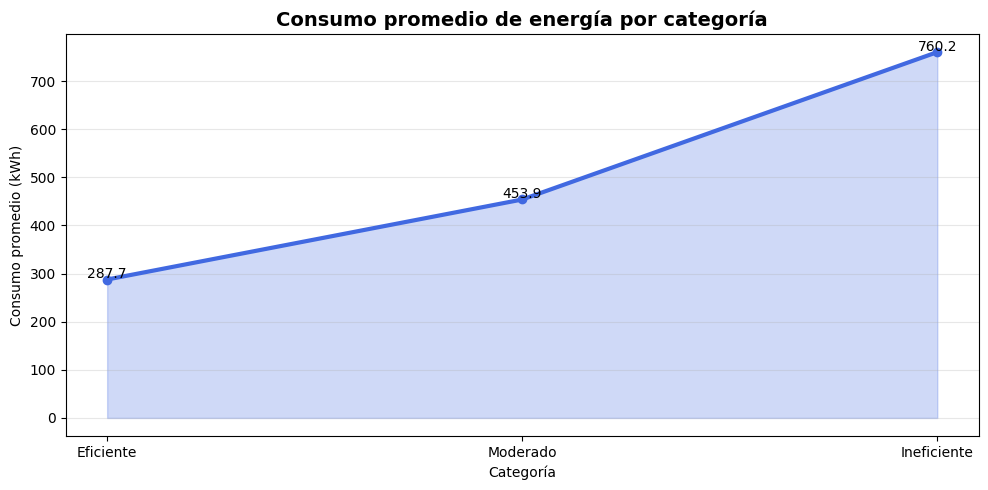

In [107]:
#Consumo de energia por categoria

consumo_promedio = (
    df.groupby("categoria")["consumo_kwh"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,5))

plt.plot(
    consumo_promedio.index,
    consumo_promedio.values,
    marker="o",
    linewidth=3,
    color="royalblue"
)

plt.fill_between(
    consumo_promedio.index,
    consumo_promedio.values,
    alpha=0.25,
    color="royalblue"
)

for x, y in zip(consumo_promedio.index, consumo_promedio.values):
    plt.text(x, y + 3, f"{y:.1f}", ha="center")

plt.title("Consumo promedio de energía por categoría", fontsize=14, weight="bold")
plt.xlabel("Categoría")
plt.ylabel("Consumo promedio (kWh)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Conclusión Consumo Promedio de Energía por Categoría

Relación Directa y Monótona Cresciente:

Existe una clara tendencia ascendente entre el nivel de ineficiencia energética y el consumo promedio de kWh.

Impacto Cuantitativo:

* Eficiente: Presenta el menor consumo medio, situándose en $287.7\text{ kWh}$.
* Moderado: Muestra un incremento del $57.8\%$ respecto al nivel eficiente, alcanzando los $453.9\text{ kWh}$.
* Ineficiente: Dispara el consumo hasta los $760.2\text{ kWh}$, lo que representa un aumento del $164.2\%$ en comparación con los hogares/comercios eficientes (más del doble de consumo).

Implicación Práctica:

La categorización de eficiencia es un excelente indicador predictivo del gasto energético. Implementar medidas de mejora energética en los segmentos "Moderado" e "Ineficiente" ofrece el mayor potencial de reducción de consumo y costo estimado.

/tmp/ipykernel_687/14603842.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


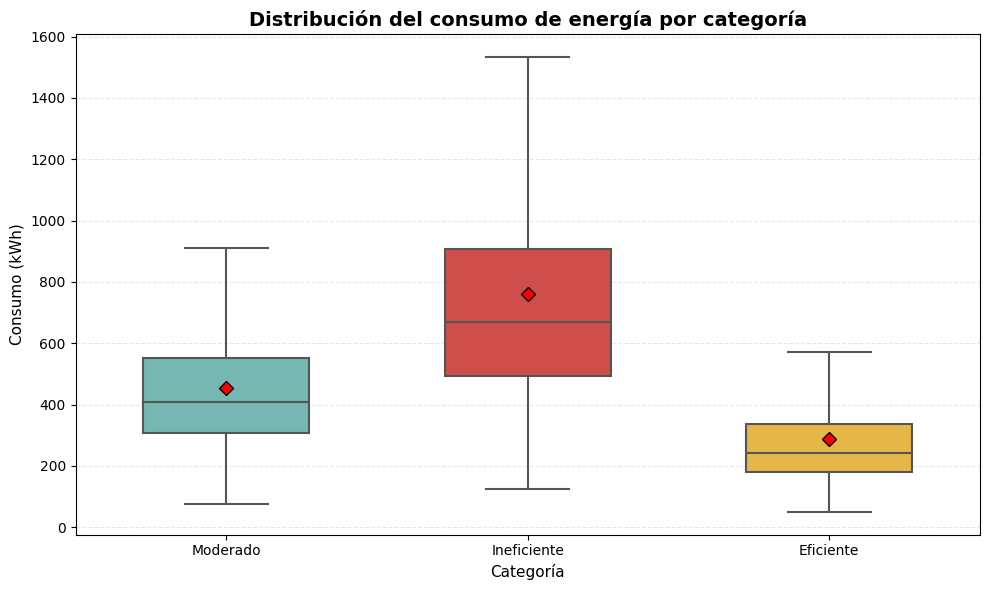

In [153]:
#Distribucion del consumo de energia

plt.figure(figsize=(10, 6))

colors = ["#6BC2BA","#E53935","#FFC02E"]
sns.boxplot(
    data=df,
    x="categoria",
    y="consumo_kwh",
    palette=colors,

    showfliers=False,
    width=0.55,
    linewidth=1.5,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.title(
    "Distribución del consumo de energía por categoría",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Categoría", fontsize=11)
plt.ylabel("Consumo (kWh)", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Conclusión Distribución del Consumo de Energía por Categoría

1. Variabilidad y Dispersión del Consumo

* Ineficiente: Muestra la mayor variabilidad de consumo (caja más ancha y bigotes más largos). Los datos oscilan desde poco más de $100\text{ kWh}$ hasta sobrepasar los $1,500\text{ kWh}$. Esto indica que en este grupo entran perfiles muy heterogéneos o casos extremos de alto consumo.
* Moderado y Eficiente: Presentan distribuciones más compactas y estables.
* En Eficiente, el $75\%$ de los registros se mantiene por debajo de aproximadamente $350\text{ kWh}$.

2. Mediana vs. Media (Sesgo hacia la derecha)

En las tres categorías, el promedio (rombo rojo) se ubica por encima de la mediana (línea horizontal):

* Eficiente: Mediana $\approx 240\text{ kWh}$ | Media $\approx 287.7\text{ kWh}$
* Moderado: Mediana $\approx 410\text{ kWh}$ | Media $\approx 453.9\text{ kWh}$
* Ineficiente: Mediana $\approx 670\text{ kWh}$ | Media $\approx 760.2\text{ kWh}$

Interpretación:

Existe una asimetría positiva (sesgo hacia la derecha) provocada por valores altos que elevan la media respecto a la mitad de la población.

3. Solapamiento de Rango (Overlapping)

Aunque las medianas se diferencian claramente (confirmando la utilidad de la categoría), existe solapamiento parcial entre los grupos (por ejemplo, los valores más altos de la categoría Eficiente se cruzan con los más bajos de Moderado).

Esto sugiere que la categoría no solo depende del consumo bruto, sino de otros factores (como el tamaño del inmueble o eficiencia por $m^2$).


Implicación para Modelado de Machine Learning

Recomendación:

Dado el sesgo hacia valores altos observable en la categoría Ineficiente, es aconsejable aplicar una transformación logarítmica al consumo o utilizar escaladores basados en rangos (RobustScaler) para evitar que los valores superiores distorsionen los algoritmos de predicción.

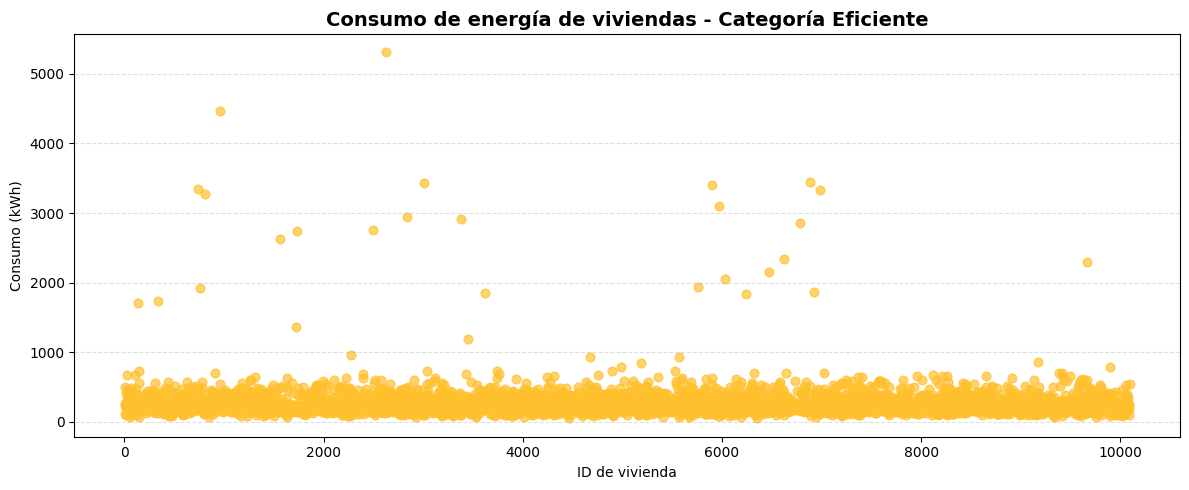

In [154]:
#Consumo de energía en la categoría eficiente

Eficiente= df[df["categoria"]=="Eficiente"]

plt.figure(figsize=(12,5))

plt.scatter(
    Eficiente["id"],
    Eficiente["consumo_kwh"],
    color="#FFC02E",
    alpha=0.7,
    s=40
)

plt.title("Consumo de energía de viviendas - Categoría Eficiente",
          fontsize=14,
          fontweight="bold")

plt.xlabel("ID de vivienda")
plt.ylabel("Consumo (kWh)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

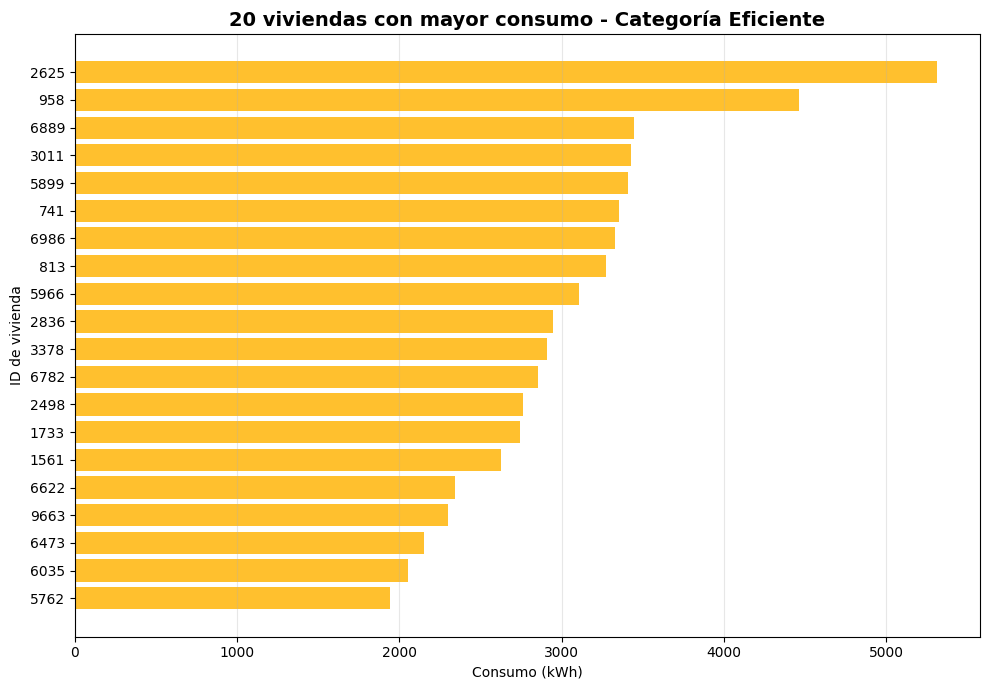

In [155]:
#20 viviendas con mayor consumo en la categoría eficiente

top20 = (
    Eficiente.nlargest(20, "consumo_kwh")
            .sort_values("consumo_kwh")
)

plt.figure(figsize=(10,7))

plt.barh(
    top20["id"].astype(str),
    top20["consumo_kwh"],
    color="#FFC02E"
)

plt.title("20 viviendas con mayor consumo - Categoría Eficiente",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Consumo (kWh)")
plt.ylabel("ID de vivienda")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

####Categoría Moderado

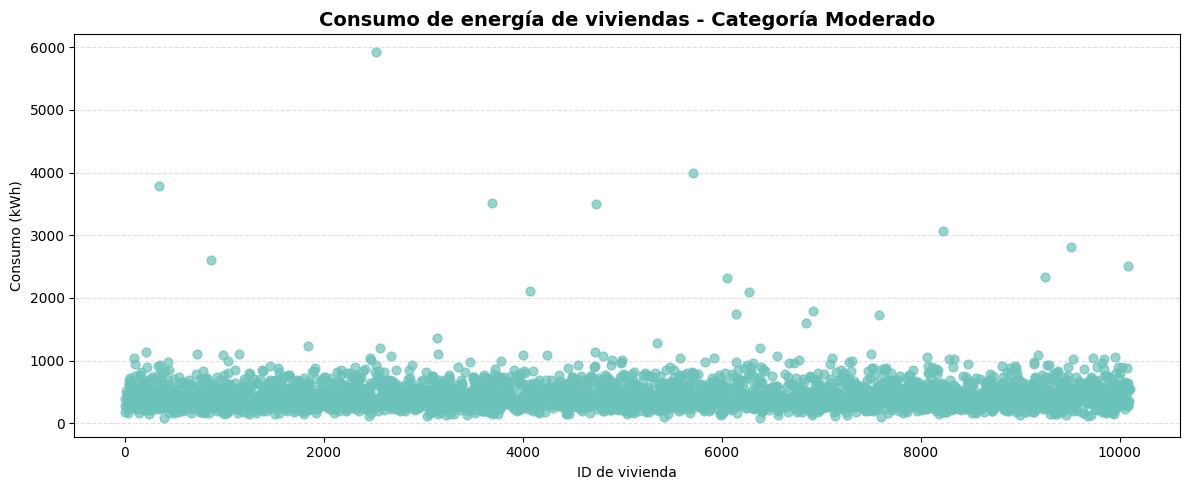

In [156]:
#Consumo de energía en la categoría moderado

Moderado= df[df["categoria"]=="Moderado"]

plt.figure(figsize=(12,5))

plt.scatter(
    Moderado["id"],
    Moderado["consumo_kwh"],
    color="#6BC2BA",
    alpha=0.7,
    s=40
)

plt.title("Consumo de energía de viviendas - Categoría Moderado",
          fontsize=14,
          fontweight="bold")

plt.xlabel("ID de vivienda")
plt.ylabel("Consumo (kWh)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

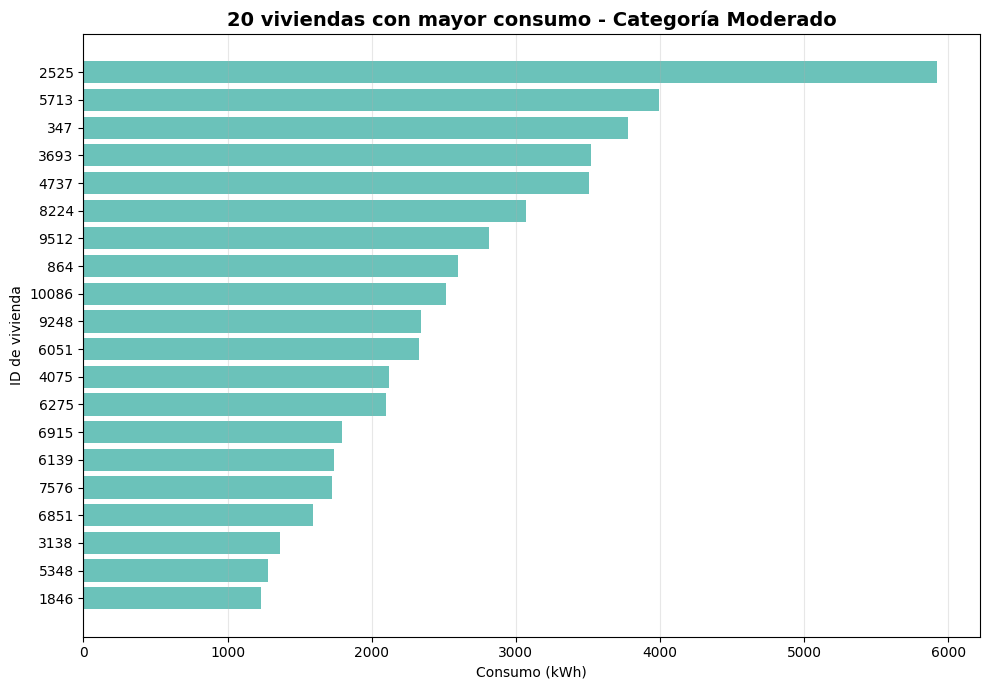

In [157]:
#20 viviendas con mayor consumo en la categoría moderado

top20 = (
    Moderado.nlargest(20, "consumo_kwh")
            .sort_values("consumo_kwh")
)

plt.figure(figsize=(10,7))

plt.barh(
    top20["id"].astype(str),
    top20["consumo_kwh"],
    color="#6BC2BA"
)

plt.title("20 viviendas con mayor consumo - Categoría Moderado",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Consumo (kWh)")
plt.ylabel("ID de vivienda")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

####Categoría Ineficiente

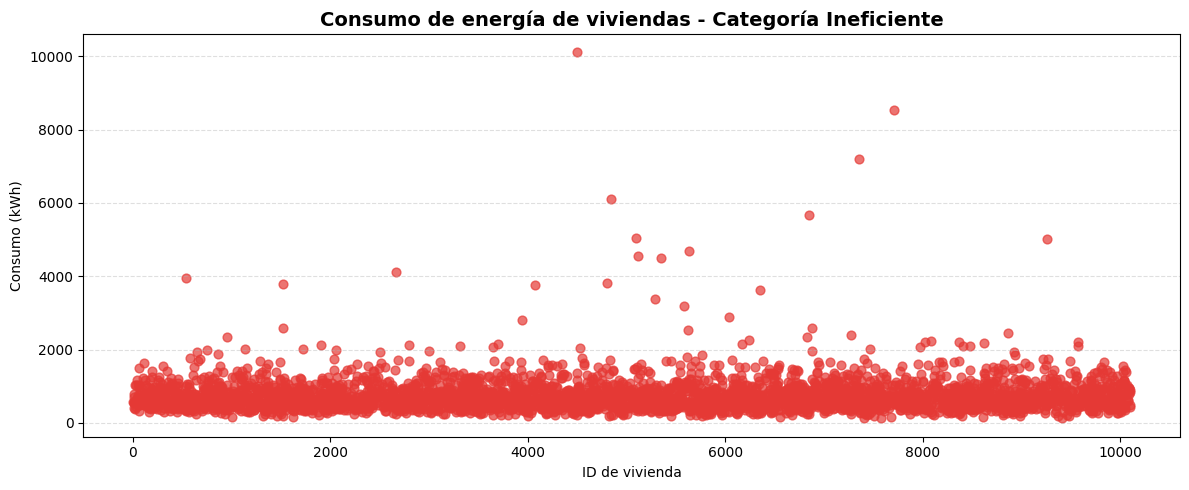

In [158]:
#Consumo de energía en la categoría ineficiente

Ineficiente= df[df["categoria"]=="Ineficiente"]

plt.figure(figsize=(12,5))

plt.scatter(
    Ineficiente["id"],
    Ineficiente["consumo_kwh"],
    color="#E53935",
    alpha=0.7,
    s=40
)

plt.title("Consumo de energía de viviendas - Categoría Ineficiente",
          fontsize=14,
          fontweight="bold")

plt.xlabel("ID de vivienda")
plt.ylabel("Consumo (kWh)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

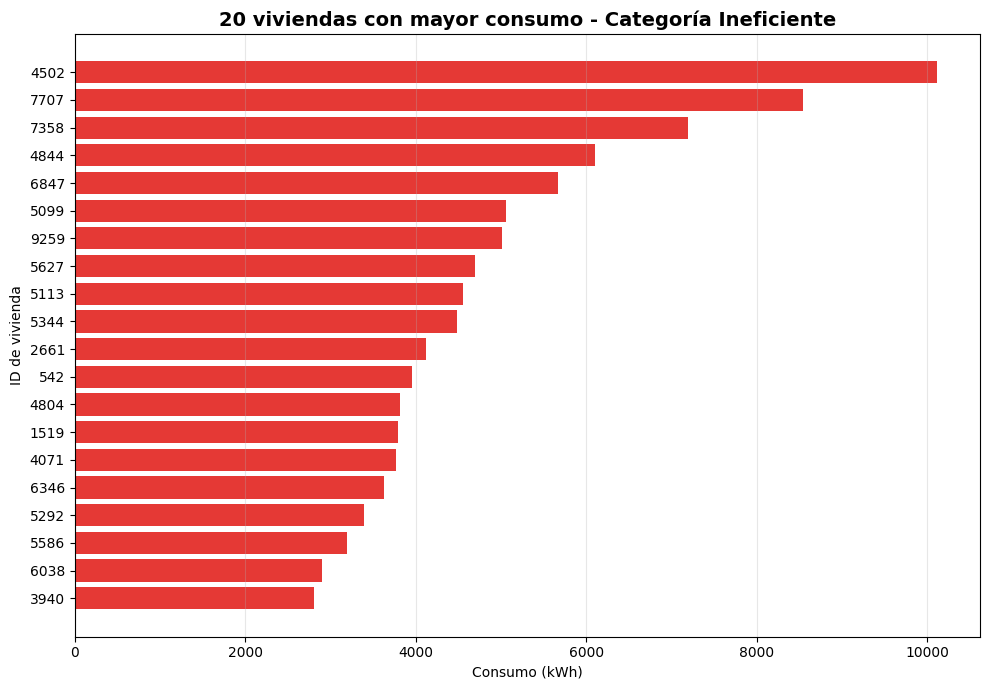

In [159]:
#20 viviendas con mayor consumo en la categoría ineficiente

top20 = (
    Ineficiente.nlargest(20, "consumo_kwh")
            .sort_values("consumo_kwh")
)

plt.figure(figsize=(10,7))

plt.barh(
    top20["id"].astype(str),
    top20["consumo_kwh"],
    color="#E53935"
)

plt.title("20 viviendas con mayor consumo - Categoría Ineficiente",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Consumo (kWh)")
plt.ylabel("ID de vivienda")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

##Correlacion

In [160]:
# 1. Seleccionar solo las variables numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# 2. Calcular la matriz de correlación de Pearson
matriz_correlacion = df_numerico.corr()

# Mostrar la tabla de correlaciones
display(matriz_correlacion)

,id,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,cantidad_personas,horas_en_casa,ingreso_mensual,aires_acondicionados,heladeras,...,lavadoras,secadoras,cantidad_equipos,electrodomesticos_eficientes,temperatura_media,consumo_kwh,horas_alto_consumo,tarifa_kwh,costo_estimado,energy_efficiency_score
id,1.000000,0.022564,0.015969,0.009751,0.006419,0.010188,0.001152,0.007804,0.005461,0.002672,...,-0.004288,0.014876,0.008900,0.002047,0.007558,0.008431,-0.007392,0.000802,0.016507,0.005739
metros_cuadrados,0.022564,1.000000,0.437087,0.249692,-0.000985,0.305574,0.003666,0.396797,0.344739,0.075175,...,0.013431,0.120714,0.291893,0.049861,-0.003493,0.200584,0.010125,-0.020865,0.248926,0.103970
habitaciones,0.015969,0.437087,1.000000,0.564798,0.002385,0.683464,-0.009978,0.387520,0.334242,0.189772,...,0.012908,0.110830,0.533828,0.042275,-0.020858,0.320406,-0.003066,-0.015339,0.411803,0.122852
baños,0.009751,0.249692,0.564798,1.000000,0.006204,0.367568,-0.013860,0.210670,0.177800,0.104235,...,0.011949,0.057459,0.287953,0.018972,0.007172,0.165358,-0.001472,-0.009338,0.216290,0.065726
antiguedad_vivienda,0.006419,-0.000985,0.002385,0.006204,1.000000,0.007411,0.016753,-0.002202,-0.012433,0.001160,...,-0.001737,-0.006675,-0.008232,-0.644186,-0.007457,0.010758,-0.009039,0.000346,0.030455,0.036551
cantidad_personas,0.010188,0.305574,0.683464,0.367568,0.007411,1.000000,-0.026705,0.260631,0.225400,0.331283,...,-0.090797,0.075885,0.727031,0.034737,-0.013529,0.412284,-0.003727,-0.006798,0.519532,0.117019
horas_en_casa,0.001152,0.003666,-0.009978,-0.013860,0.016753,-0.026705,1.000000,0.000635,0.015599,-0.060075,...,0.119572,0.002999,0.060838,-0.003930,-0.007984,0.397569,0.133001,0.001523,0.494031,0.599120
ingreso_mensual,0.007804,0.396797,0.387520,0.210670,-0.002202,0.260631,0.000635,1.000000,0.499818,0.067897,...,0.009686,0.255690,0.318742,0.122778,-0.003399,0.202944,0.009418,-0.003333,0.255157,0.087740
aires_acondicionados,0.005461,0.344739,0.334242,0.177800,-0.012433,0.225400,0.015599,0.499818,1.000000,0.044841,...,0.012767,0.151168,0.402939,0.066757,-0.017414,0.248399,0.008089,-0.017423,0.312607,0.094259
heladeras,0.002672,0.075175,0.189772,0.104235,0.001160,0.331283,-0.060075,0.067897,0.044841,1.000000,...,-0.452505,0.012561,0.299539,0.004234,-0.013208,0.121942,-0.015449,0.001133,0.160103,-0.020034


In [161]:
# Correlación específica con respecto a consumo_kwh
matriz_correlacion['consumo_kwh'].sort_values(ascending=False)

,consumo_kwh
consumo_kwh,1.000000
costo_estimado,0.753080
energy_efficiency_score,0.568987
cantidad_equipos,0.448779
cantidad_personas,0.412284
computadoras,0.410052
horas_en_casa,0.397569
televisores,0.335430
habitaciones,0.320406
aires_acondicionados,0.248399


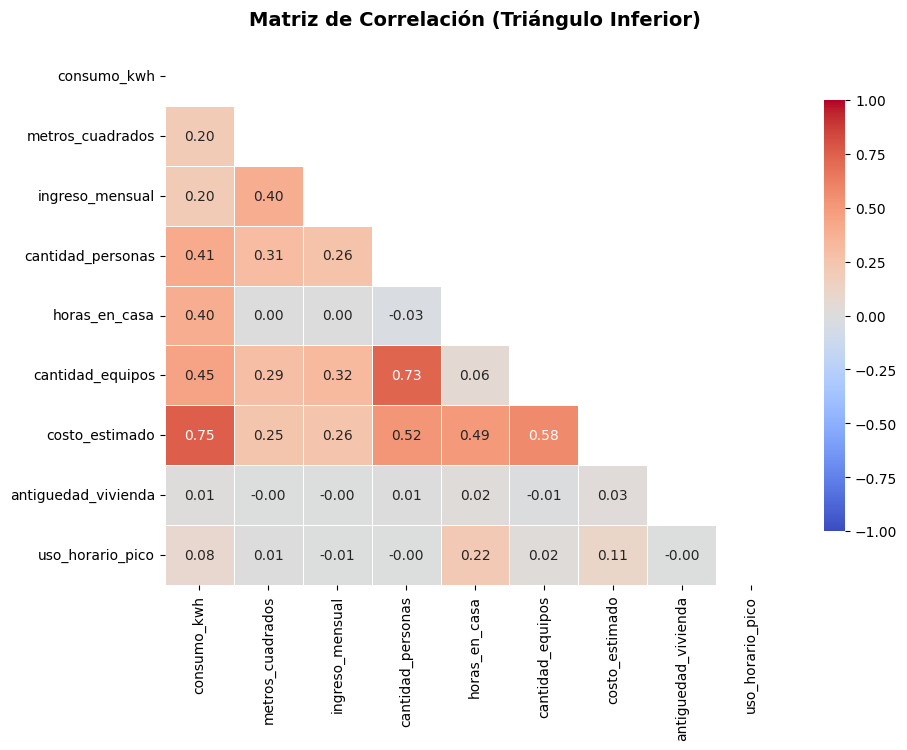

In [169]:
# 1. Seleccionar las variables de interés
cols_clave = [
    'consumo_kwh', 'metros_cuadrados', 'ingreso_mensual',
    'cantidad_personas', 'horas_en_casa', 'cantidad_equipos',
    'costo_estimado', 'antiguedad_vivienda','uso_horario_pico'
]

# 2. Calcular la matriz de correlación
corr = df[cols_clave].corr()

# 3. Crear una máscara para ocultar la mitad superior redundante y la diagonal
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Configurar el tamaño de la figura
plt.figure(figsize=(10, 7))

# 5. Dibujar el Heatmap aplicando la máscara
sns.heatmap(
    corr,
    mask=mask,           # Oculta el triángulo superior
    annot=True,          # Muestra los valores numéricos
    fmt=".2f",           # Redondea a 2 decimales
    cmap='coolwarm',     # Color de mapa (rojo=positivo, azul=negativo)
    vmin=-1, vmax=1,     # Límites de la escala de correlación
    linewidths=0.5,      # Líneas divisorias
    cbar_kws={"shrink": 0.8} # Ajusta el tamaño de la barra lateral
)

plt.title('Matriz de Correlación (Triángulo Inferior)', fontsize=14, fontweight='bold', pad=15)
plt.show()

Conclusión Matriz de Correlación de Variables

1. Principales Drivers del Consumo Energético (consumo_kwh)

* costo_estimado ($0.75$): Presenta una correlación positiva fuerte, lo cual valida la consistencia interna de los datos (a mayor consumo, mayor costo facturado).

* cantidad_equipos ($0.45$) y cantidad_personas ($0.41$): Tienen una correlación positiva moderada con el consumo. Indican que la carga operativa (aparatos conectados) y la ocupación del hogar son determinantes directos en el incremento de kWh.

* horas_en_casa ($0.40$): También impacta de forma directa y moderada en el consumo.

* metros_cuadrados ($0.20$) e ingreso_mensual ($0.20$): Presentan una relación positiva débil, sugiriendo que el tamaño físico o el poder adquisitivo por sí solos no garantizan un consumo proporcionalmente mayor si no hay más equipamiento o personas.

2. Multicolinealidad Notable Entre Variables
Independientes

* cantidad_personas vs. cantidad_equipos ($0.73$): Existe una alta correlación directa. A mayor número de habitantes en la vivienda, mayor es el parque de electrodomésticos instalados.

* costo_estimado vs. cantidad_equipos ($0.58$), cantidad_personas ($0.52$) y horas_en_casa ($0.49$): Confirman la fuerte dependencia del gasto final con las variables operativas del hogar.

* metros_cuadrados vs. ingreso_mensual ($0.40$): Muestra que hogares con mayores ingresos tienden a tener propiedades más amplias.

3. Variables Desconectadas / Sin Relación
Línea

* antiguedad_vivienda: Presenta coeficientes prácticamente nulos ($\approx 0.00$ a $0.03$) con todas las demás variables. Esto demuestra que los años de la propiedad no determinan linealmente el consumo, el equipamiento ni los ingresos.

* horas_en_casa vs. metros_cuadrados / ingreso_mensual ($0.00$):
El tiempo de permanencia en el inmueble es totalmente independiente de la dimensión física de la vivienda o la capacidad económica.

Implicaciones para la Fase de Modelado (Machine Learning)

Riesgo de Multicolinealidad:

  Al entrenar modelos de regresión lineal, la fuerte correlación entre cantidad_personas y cantidad_equipos ($0.73$) puede inflar la varianza de los coeficientes. Se recomienda evaluar la eliminación de una de ellas o combinar sus efectos mediante un atributo derivado (ej. equipos por persona).

Preserva del Target:

  La variable costo_estimado ($0.75$) debe excluirse de las variables predictoras (features) si el objetivo es predecir consumo_kwh, para evitar fugas de información (data leakage).